Plots of Cp vs theta on cylinder surface for different meshes + literature reference (if available)

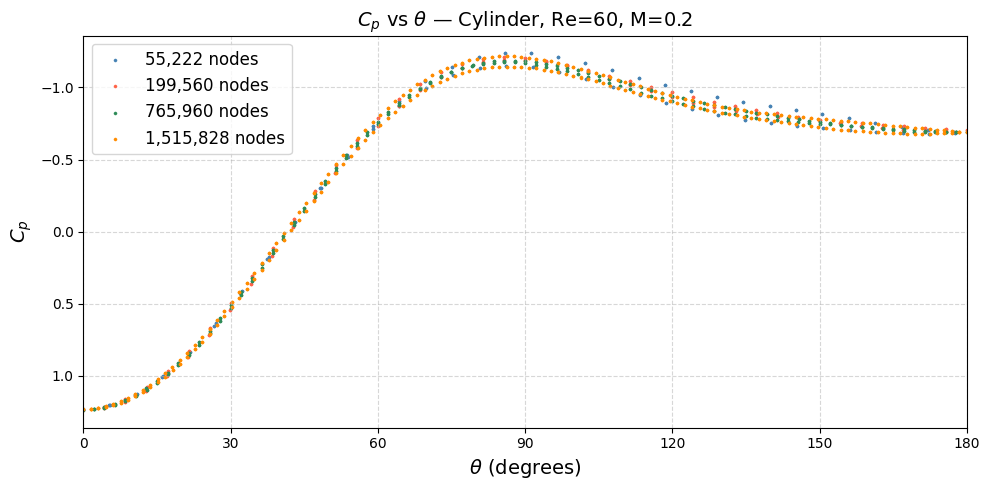

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from pyau3d.utils import PltFileUtils, UnkFileUtils
from pyau3d.pv.loader.au3d import arrays2vtk

# ── Parameters ─────────────────────────────────────────────────────────────────
RE    = 60
MACH  = 0.2
gamma = 1.4
R_gas = 287.0

# farfield conditions — must match solver values
T_inf   = 288.15
P_inf   = 1.32702          # Pa
rho_inf = P_inf / (R_gas * T_inf)
u_inf   = MACH * np.sqrt(gamma * R_gas * T_inf)
q_inf   = 0.5 * rho_inf * u_inf**2   # dynamic pressure for Cp

# ── Mesh list — update to your actual sizes ────────────────────────────────────
mesh_list = [55222, 199560, 765960, 1515828]
# mesh_list = [1515828]
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']
base_dir  = "/home/ahf25/CFD_2d_cylinder_all/Steady/Ma0.2/v3_mesh"
wall_flag = 7

# ── Helper ─────────────────────────────────────────────────────────────────────
def extract_cp(mesh):
    case_dir = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
    pltfile  = PltFileUtils(f"{case_dir}/cylinder.plt")
    rstfile  = UnkFileUtils(f"{case_dir}/cylinder.rst", extend=False)
    rstfile._primitive()

    side_coords, side_nodes, _ = pltfile.extract_surface(flag=wall_flag)
    surface_p = rstfile.p[side_nodes]
    surface_x = side_coords[:, 0]

    theta = np.arccos(np.clip(-surface_x / 0.5, -1.0, 1.0)) * 180.0 / np.pi
    cp    = (surface_p - P_inf) / q_inf

    idx = np.argsort(theta)
    return theta[idx], cp[idx]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for mesh, color in zip(mesh_list, colors):
    try:
        theta, cp = extract_cp(mesh)
        ax.scatter(theta, cp, color=color, 
                   s=5, linewidths=0.3, label=f'{mesh:,} nodes')
    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")

# ── Literature: Grove et al. (1964), Re=60 (uncomment if you have the CSV) ────
# import pandas as pd
# cp_ref = pd.read_csv("/path/to/grove1964_cp_Re60.csv")
# ax.plot(cp_ref['theta'], cp_ref['cp'],
#         color='black', marker='o', markersize=4, linewidth=1.2,
#         label='Grove et al. (1964)')

ax.invert_yaxis()
ax.set_xlabel(r'$\theta$ (degrees)', fontsize=14)
ax.set_ylabel(r'$C_p$', fontsize=14)
ax.set_title(rf'$C_p$ vs $\theta$ — Cylinder, Re={RE}, M={MACH}', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim([0, 180])
ax.set_xticks(range(0, 181, 30))
plt.tight_layout()
plt.savefig(f"cp_vs_theta_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()

Plots of normalised x-velocity vs x/D from x/D = 0.5 to 3 for different meshes + literature reference (if available)

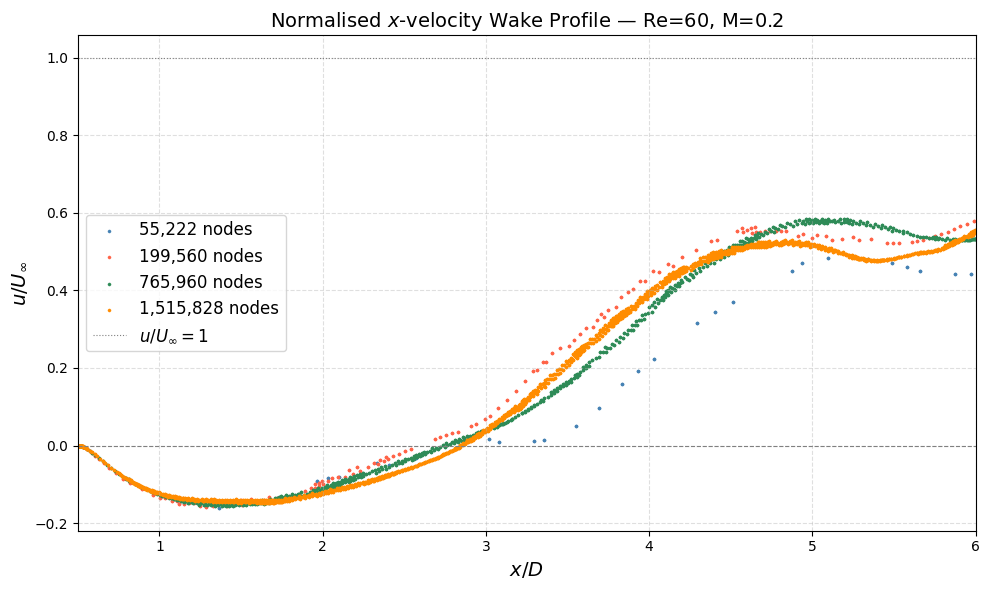

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyau3d.utils import PltFileUtils, UnkFileUtils

# ── Parameters ─────────────────────────────────────────────────────────────────
RE    = 60
MACH  = 0.2
gamma = 1.4
R_gas = 287.0
D     = 1.0               # cylinder diameter

T_inf = 288.15
u_inf = MACH * np.sqrt(gamma * R_gas * T_inf)   # ~68.05 m/s

# wake centreline filter
x_start   = 0.5          # rear of cylinder (x/D)
x_end     = 6.0
y_tol     = 1.5e-2         # y-tolerance for centreline

# ── Mesh list — update to your actual sizes ────────────────────────────────────
mesh_list = [55222, 199560, 765960, 1515828]
# mesh_list = [1515828]
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']
base_dir  = "/home/ahf25/CFD_2d_cylinder_all/Steady/Ma0.2/v3_mesh"

# ── Helper ─────────────────────────────────────────────────────────────────────
def extract_wake_profile(mesh):
    case_dir = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
    pltfile  = PltFileUtils(f"{case_dir}/cylinder.plt")
    rstfile  = UnkFileUtils(f"{case_dir}/cylinder.rst", extend=False)
    rstfile._primitive()

    coord = pltfile.coord
    ux    = rstfile.ux

    # filter centreline nodes in wake
    mask = (
        (coord[:, 0] >= x_start) &
        (coord[:, 0] <= x_end)   &
        (np.abs(coord[:, 1]) < y_tol)
    )

    x_norm = coord[mask, 0] / D
    u_norm = ux[mask] / u_inf

    idx = np.argsort(x_norm)
    return x_norm[idx], u_norm[idx]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for mesh, color in zip(mesh_list, colors):
    try:
        x_norm, u_norm = extract_wake_profile(mesh)
        ax.scatter(x_norm, u_norm, color=color,
                   s=5, linewidths=0.3, label=f'{mesh:,} nodes')
    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")

# for mesh, color, marker in zip(mesh_list, colors, markers):
#     try:
#         x_norm, u_norm = extract_wake_profile(mesh)
#         ax.plot(x_norm, u_norm, color=color, linewidth=1.8, label=f'{mesh:,} nodes')
#     except FileNotFoundError:
#         print(f"Skipping mesh {mesh}: files not found")


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhline(1, color='gray', linewidth=0.8, linestyle=':', label=r'$u/U_\infty = 1$')

ax.set_xlabel(r'$x/D$', fontsize=14)
ax.set_ylabel(r'$u / U_\infty$', fontsize=14)
ax.set_title(rf'Normalised $x$-velocity Wake Profile — Re={RE}, M={MACH}', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim([0.5, 6.0])
plt.tight_layout()
plt.savefig(f"u_wake_profile_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()

Computing pressure drag coefficient for 4 meshes

In [3]:
def area_normals(coord, ifac3=None, ifac4=None):
    """
    Compute area-weighted normal vectors (Ax, Ay, Az) at each nodes,
    accumulated from triangle and/or quadrilateral faces. No PolyData is
    built; only the (N, 3) array is returned.
 
    For each face, the area-normal vector is:
        triangle : 0.5 * cross(v1 - v0, v2 - v0)
        quad     : sum of the two triangle area-normals from splitting
                   the quad (0,1,2) + (0,2,3)
    Each face's area-normal is split equally among its vertices and summed.

    That is how it accounted from the node-centered formulation
 
    Args:
        coord : (N, 3) array of mesh point coordinates
        ifac3 : (M3, 3) array of triangle connectivity, zero-based (or None)
        ifac4 : (M4, 4) array of quad connectivity, zero-based (or None)
 
    Returns:
        anor : (N, 3) array of area-weighted normals (Ax, Ay, Az) per point
    """
    coord = np.asarray(coord, dtype=float)
    anor = np.zeros_like(coord)
 
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3)
        v0, v1, v2 = coord[ifac3[:, 0]], coord[ifac3[:, 1]], coord[ifac3[:, 2]]
        face_anor = 0.5 * np.cross(v1 - v0, v2 - v0)   # (M3, 3)
        contrib = -face_anor / 3.0                      # sign matches ref code
        for k in range(3):
            np.add.at(anor, ifac3[:, k], contrib)
 
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4)
        v0, v1, v2, v3 = (coord[ifac4[:, 0]], coord[ifac4[:, 1]],
                          coord[ifac4[:, 2]], coord[ifac4[:, 3]])
        n1 = 0.5 * np.cross(v1 - v0, v2 - v0)
        n2 = 0.5 * np.cross(v2 - v0, v3 - v0)
        face_anor = n1 + n2                              # (M4, 3)
        contrib = -face_anor / 4.0
        for k in range(4):
            np.add.at(anor, ifac4[:, k], contrib)
 
    return anor

def compute_force_coefficient(flag, direction, U_inf, rho_inf, surface_area,
                              pltfile, rstfile, coord):
    """
    Compute the lift coefficient on a surface identified by `flag`,
    projected along `direction`.

    Parameters
    ----------
    flag : int
        Surface flag identifying which boundary/group to extract (e.g. 7 = cylinder surface).
    direction : array-like, shape (3,)
        Prescribed direction vector to project the force onto (e.g. [0, 1, 0] for lift in y).
    U_inf : float
        Farfield velocity (m/s).
    rho_inf : float
        Farfield density (kg/m^3).
    surface_area : float
        Reference surface area (m^2).
    pltfile : PltFileUtils
        Mesh/geometry file object with `extract_surface_real` method.
    rstfile : object
        Result file object with `.p` (static pressure) array.
    coord : np.ndarray
        Global nodal coordinates array (0-based indexing).

    Returns
    -------
    CF : float
        force coefficient. (it could be lift or drag, depends on prescribed direction)
    """
    # extract nodes, ifac3 and ifac4 on the specified surface
    global_surface_nodes, ifac3, ifac4 = pltfile.extract_surface_real(flag=flag)

    # get surface coordinates (0-based indexing)
    global_surface_coord = coord[global_surface_nodes]

    # get area normals
    surface_area_normals = area_normals(global_surface_coord, ifac3, ifac4)

    # extract static pressure on the surface
    surface_pressure = rstfile.p[global_surface_nodes]

    # project force onto prescribed direction
    force = np.sum(surface_pressure * np.dot(surface_area_normals, direction), axis=0)

    # nondimensionalize
    CF = force / (0.5 * rho_inf * U_inf**2 * surface_area)

    return CF



        Mesh     CD_pressure
------------------------------
      55,222        1.130330
     199,560        1.140300
     765,960        1.126414
   1,515,828        1.121613


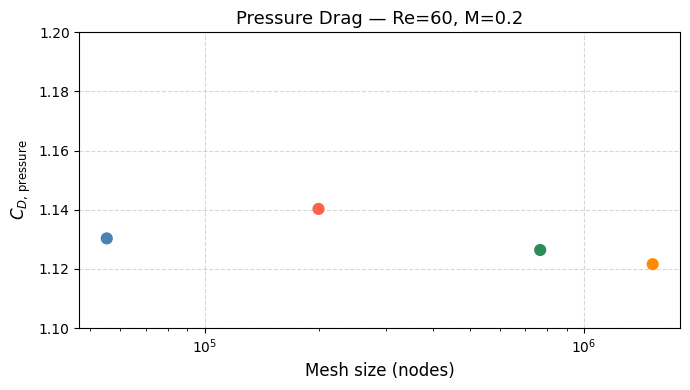

In [4]:
# ── Pressure drag coefficient for 4 meshes ─────────────────────────────────────
# reuses compute_lift_coefficient with drag direction [1, 0, 0]

# reference parameters for Re=60, M=0.2
rho_inf      = P_inf / (R_gas * T_inf)   # ~1.604e-5 kg/m³
q_inf_ref    = 0.5 * rho_inf * u_inf**2  # dynamic pressure
span         = 0.1                        # span (m)
D            = 1
surface_area = span * D            # D × span = 1×1 m²
wall_flag    = 7                          # noslip cylinder wall
drag_dir     = [1, 0, 0]                 # x-direction

print(f"\n{'Mesh':>12}  {'CD_pressure':>14}")
print("-" * 30)

cd_list = []
for mesh in mesh_list:
    try:
        case_dir = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
        pltfile_m = PltFileUtils(f"{case_dir}/cylinder.plt")
        rstfile_m = UnkFileUtils(f"{case_dir}/cylinder.rst", extend=False)
        rstfile_m._primitive()
        coord_m = pltfile_m.coord

        CD = compute_force_coefficient(
            wall_flag, drag_dir,
            u_inf, rho_inf, surface_area,
            pltfile_m, rstfile_m, coord_m)

        cd_list.append(CD)
        print(f"{mesh:>12,}  {CD:>14.6f}")

    except FileNotFoundError:
        cd_list.append(None)
        print(f"{mesh:>12,}  {'file not found':>14}")

fig, ax = plt.subplots(figsize=(7, 4))
valid = [(m, cd) for m, cd in zip(mesh_list, cd_list) if cd is not None]
ax.scatter([m for m, _ in valid], [cd for _, cd in valid],
           color=colors[:len(valid)], marker='o', s=60, zorder=5)
ax.set_xscale('log')
ax.set_ylim([1.10,1.2])
ax.set_xlabel('Mesh size (nodes)', fontsize=12)
ax.set_ylabel(r'$C_{D,\,\mathrm{pressure}}$', fontsize=12)
ax.set_title(rf'Pressure Drag — Re={RE}, M={MACH}', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"cd_pressure_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()

Contour plots for 4 meshes

In [5]:
def specific_energy(rho, p, ux, uy, uz, gamma=1.4):
    return p / ((gamma - 1.0) * rho) + 0.5 * (ux**2 + uy**2 + uz**2)

def conservative_variables(rst, GAMMA):
    """Return conservative variables U on the surface."""
    E = specific_energy(rst.rho, rst.p, rst.ux, rst.uy, rst.uz, GAMMA)

    U = np.column_stack((
        rst.rho,
        rst.rho * rst.ux,
        rst.rho * rst.uy,
        rst.rho * rst.uz,
        rst.rho * E
    ))
    return U

In [6]:
# ── Contour plot for all 4 meshes ─────────────────────────────────────────────
scalar = "rhou"   # change to any of: rho, rhou, rhov, rhow, rhoE

names = ['rho', 'rhou', 'rhov', 'rhow', 'rhoE']

for mesh in mesh_list:
    try:
        case_dir  = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
        pltfile_c = PltFileUtils(f"{case_dir}/cylinder.plt")
        rstfile_c = UnkFileUtils(f"{case_dir}/cylinder.rst", extend=False)
        rstfile_c._primitive()
        U_list_c  = conservative_variables(rstfile_c, gamma)

        mesh_vtk = arrays2vtk(pltfile_c)
        block_c  = pv.wrap(pv.wrap(mesh_vtk.GetBlock(0)).GetBlock(0))

        for i, name in enumerate(names):
            block_c.point_data[name] = U_list_c[:, i]

        pl = pv.Plotter(notebook=False)
        pl.add_mesh(block_c, scalars=scalar, cmap='RdBu',
                    show_edges=False, opacity=0.9,
                    scalar_bar_args={'title': r'$\rho u$',
                                     'title_font_size': 40,
                                     'label_font_size': 20})
        pl.view_xy()
        pl.camera.parallel_projection = True
        pl.save_graphic(f"Re{RE}_M{MACH}_{mesh}_{scalar}.svg")
        # pl.show()

    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")



In [ ]:
# ── Residual vs iterations for all 4 meshes ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for mesh, color in zip(mesh_list, colors):
    try:
        case_dir  = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
        data      = np.loadtxt(f"{case_dir}/cylinder.res")
        iters     = data[:, 0]
        log_res   = np.log10(data[:, 1])
        ax.plot(iters, log_res, color=color, linewidth=1.8, label=f'{mesh:,} nodes')
    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")

ax.set_xlabel("Iterations", fontsize=12)
ax.set_ylabel(r"$\log_{10}$ (density residual)", fontsize=12)
ax.set_title(rf"Density Residual — Re={RE}, M={MACH}", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig(f"residual_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()